In [2]:
import os
import json
import time
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Config

In [3]:
SHARED_DATASET_FILE = "../data/processed/cleaned_emotions_shared.csv"
SHARED_SPLIT_FILE   = "../data/splits/shared_split.json"

MODEL_NAME     = "roberta-base"
MODEL_SAVE_DIR = "../models/roberta_model"
PRED_FILE      = "../data/processed/roberta_test_predictions.csv"
SUMMARY_FILE   = "../data/processed/roberta_summary.csv"
DISPLAY_NAME   = "RoBERTa"

MAX_LEN    = 64
BATCH_SIZE = 16
EPOCHS     = 5
LR         = 2e-5
PATIENCE   = 2

LABELS = ["angry", "disgust", "fear", "happy", "neutral", "sad"]

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

total_start_time = time.time()

Using device: cuda


### Load Data

In [4]:
df = pd.read_csv(SHARED_DATASET_FILE)

with open(SHARED_SPLIT_FILE, "r", encoding="utf-8") as f:
    split_dict = json.load(f)

train_df = df[df["row_id"].isin(split_dict["train_ids"])].copy()
val_df   = df[df["row_id"].isin(split_dict["val_ids"])].copy()
test_df  = df[df["row_id"].isin(split_dict["test_ids"])].copy()

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTotal emotion classes:", df["label"].nunique())
print("Emotion labels:", sorted(df["label"].unique().tolist()))

print("\nAll data label counts:")
print(df["label"].value_counts().sort_index())

Train: (1512, 3)
Val  : (324, 3)
Test : (324, 3)

Total emotion classes: 6
Emotion labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']

All data label counts:
label
angry      326
disgust    427
fear       395
happy      234
neutral    500
sad        278
Name: count, dtype: int64


### Label Encoding

In [5]:
label_encoder = LabelEncoder()
label_encoder.fit(LABELS)

y_train = label_encoder.transform(train_df["label"])
y_val   = label_encoder.transform(val_df["label"])
y_test  = label_encoder.transform(test_df["label"])

num_classes = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)
print("Number of classes:", num_classes)

Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']
Number of classes: 6


### Tokenizer & Dataset

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = EmotionDataset(train_df["text"].tolist(), y_train, tokenizer, MAX_LEN)
val_dataset   = EmotionDataset(val_df["text"].tolist(),   y_val,   tokenizer, MAX_LEN)
test_dataset  = EmotionDataset(test_df["text"].tolist(),  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Train batches : 95
Val batches   : 21
Test batches  : 21


### Model

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_classes)
model = model.to(device)
print(f"Model   : {MODEL_NAME}")
print(f"Params  : {sum(p.numel() for p in model.parameters()):,}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6005.62it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model   : roberta-base
Params  : 124,650,246


### Train

In [8]:
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += outputs.loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return total_loss / len(loader), correct / total


optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss    = float("inf")
patience_counter = 0

train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler)
    vl_loss, vl_acc = eval_epoch(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"Epoch {epoch}/{EPOCHS}  |  Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  |  Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

    if vl_loss < best_val_loss:
        best_val_loss    = vl_loss
        patience_counter = 0
        model.save_pretrained(MODEL_SAVE_DIR)
        tokenizer.save_pretrained(MODEL_SAVE_DIR)
        print("  -> Best model saved")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

train_elapsed = time.time() - train_start
print(f"\nTraining time: {train_elapsed:.2f} seconds")

Epoch 1/5  |  Train Loss: 1.3906  Acc: 0.4702  |  Val Loss: 0.3645  Acc: 0.9074


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.76it/s]


  -> Best model saved
Epoch 2/5  |  Train Loss: 0.2988  Acc: 0.9067  |  Val Loss: 0.1810  Acc: 0.9259


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.61it/s]


  -> Best model saved
Epoch 3/5  |  Train Loss: 0.1291  Acc: 0.9610  |  Val Loss: 0.2361  Acc: 0.9352
Epoch 4/5  |  Train Loss: 0.0686  Acc: 0.9821  |  Val Loss: 0.2478  Acc: 0.9414

Early stopping at epoch 4

Training time: 39.37 seconds


### Evaluate

In [9]:
best_model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_DIR)
best_model = best_model.to(device)
best_model.eval()

all_preds = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)
        preds   = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs        = np.array(all_probs)
test_pred_labels = label_encoder.inverse_transform(all_preds)
test_true_labels = label_encoder.inverse_transform(y_test)

acc               = accuracy_score(test_true_labels, test_pred_labels)
f1_macro          = f1_score(test_true_labels, test_pred_labels, average="macro")
f1_weighted       = f1_score(test_true_labels, test_pred_labels, average="weighted")
precision_macro   = precision_score(test_true_labels, test_pred_labels, average="macro",    zero_division=0)
precision_weighted = precision_score(test_true_labels, test_pred_labels, average="weighted", zero_division=0)

print(f"\n===== {DISPLAY_NAME} RESULT =====")
print("Accuracy          :", acc)
print("F1 Macro          :", f1_macro)
print("F1 Weighted       :", f1_weighted)
print("Precision Macro   :", precision_macro)
print("Precision Weighted:", precision_weighted)
print("\nClassification Report:")
print(classification_report(test_true_labels, test_pred_labels))
print("Confusion Matrix:")
print(confusion_matrix(test_true_labels, test_pred_labels, labels=LABELS))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6176.05it/s]



===== RoBERTa RESULT =====
Accuracy          : 0.9382716049382716
F1 Macro          : 0.9484147715858257
F1 Weighted       : 0.937734902686384
Precision Macro   : 0.9464537648144206
Precision Weighted: 0.9378629560414624

Classification Report:
              precision    recall  f1-score   support

       angry       0.98      1.00      0.99        49
     disgust       0.94      0.97      0.95        64
        fear       0.87      0.88      0.88        60
       happy       1.00      1.00      1.00        35
     neutral       0.91      0.85      0.88        75
         sad       0.98      1.00      0.99        41

    accuracy                           0.94       324
   macro avg       0.95      0.95      0.95       324
weighted avg       0.94      0.94      0.94       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 0 62  1  0  0  1]
 [ 0  1 53  0  6  0]
 [ 0  0  0 35  0  0]
 [ 1  3  7  0 64  0]
 [ 0  0  0  0  0 41]]


### Save

In [10]:
pred_col       = f"{DISPLAY_NAME.lower()}_pred"
confidence_col = f"{DISPLAY_NAME.lower()}_confidence"

pred_df = test_df[["row_id", "text", "label"]].copy().reset_index(drop=True)
pred_df[pred_col]       = test_pred_labels
pred_df[confidence_col] = all_probs.max(axis=1)
pred_df.to_csv(PRED_FILE, index=False, encoding="utf-8-sig")

summary_df = pd.DataFrame([{
    "Model":              DISPLAY_NAME,
    "Accuracy":           acc,
    "F1_Macro":           f1_macro,
    "F1_Weighted":        f1_weighted,
    "Train_Time_Seconds": round(train_elapsed, 4),
    "Num_Classes":        num_classes
}])
summary_df.to_csv(SUMMARY_FILE, index=False, encoding="utf-8-sig")

total_elapsed = time.time() - total_start_time

print("\n===== Summary =====")
print(summary_df)
print(f"\nSaved:")
print("-", PRED_FILE)
print("-", SUMMARY_FILE)
print(f"\nTotal {DISPLAY_NAME} pipeline time: {total_elapsed:.2f} seconds")
print("Done")


===== Summary =====
     Model  Accuracy  F1_Macro  F1_Weighted  Train_Time_Seconds  Num_Classes
0  RoBERTa  0.938272  0.948415     0.937735             39.3681            6

Saved:
- ../data/processed/roberta_test_predictions.csv
- ../data/processed/roberta_summary.csv

Total RoBERTa pipeline time: 53.85 seconds
Done


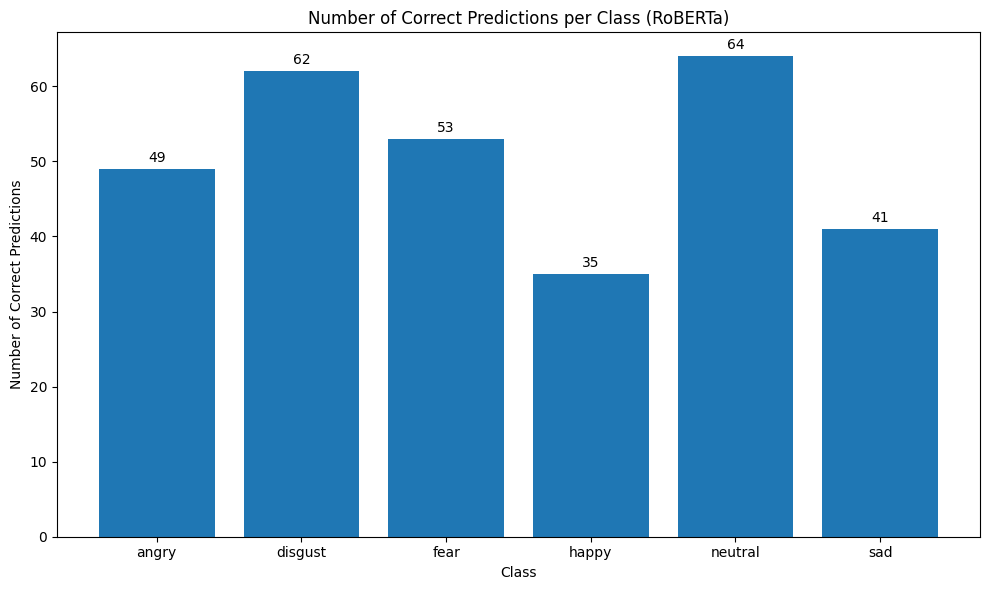

In [11]:
correct_counts = []
for label in LABELS:
    count = ((pred_df["label"] == label) & (pred_df[pred_col] == label)).sum()
    correct_counts.append(count)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(LABELS, correct_counts, label=DISPLAY_NAME)
ax.set_xlabel("Class")
ax.set_ylabel("Number of Correct Predictions")
ax.set_title(f"Number of Correct Predictions per Class ({DISPLAY_NAME})")
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()


RoBERTa Confusion Matrix


,angry,disgust,fear,happy,neutral,sad
angry,49,0,0,0,0,0
disgust,0,62,1,0,0,1
fear,0,1,53,0,6,0
happy,0,0,0,35,0,0
neutral,1,3,7,0,64,0
sad,0,0,0,0,0,41


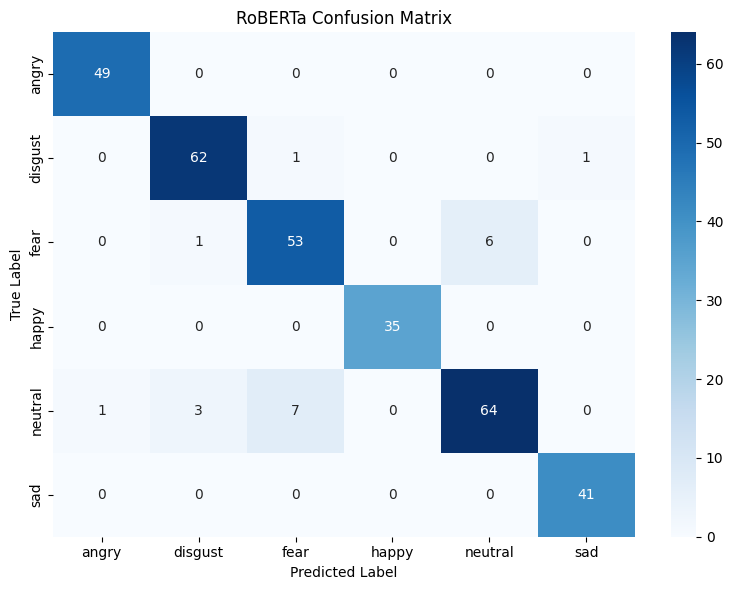

In [12]:
cm    = confusion_matrix(pred_df["label"], pred_df[pred_col], labels=LABELS)
cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)

print("\n" + "=" * 60)
print(f"{DISPLAY_NAME} Confusion Matrix")
print("=" * 60)
display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"{DISPLAY_NAME} Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

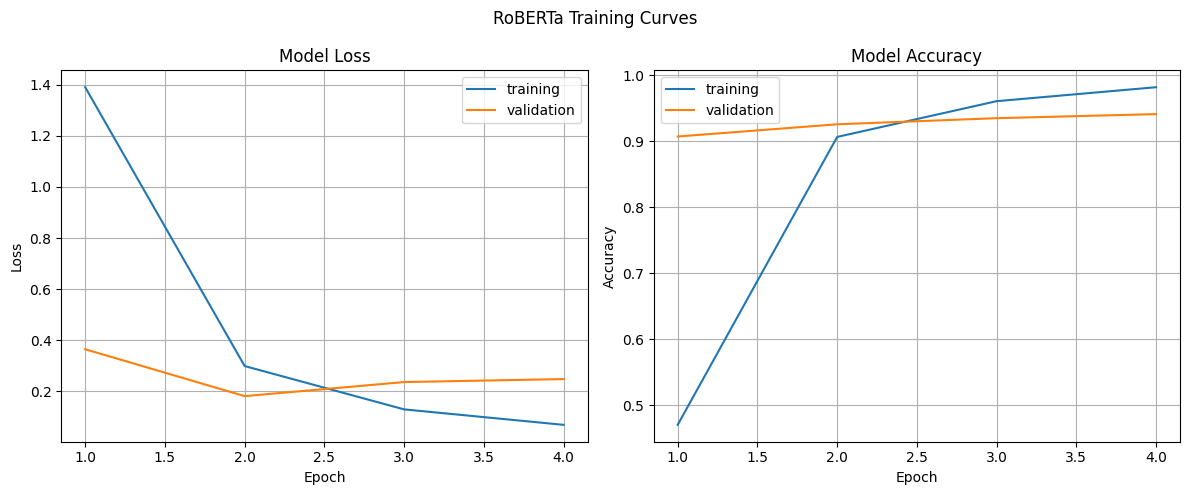

In [13]:
train_loss   = history["train_loss"]
val_loss     = history["val_loss"]
train_acc    = history["train_acc"]
val_acc      = history["val_acc"]
epochs_range = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range, train_loss, label="training")
axes[0].plot(epochs_range, val_loss,   label="validation")
axes[0].set_title("Model Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, train_acc, label="training")
axes[1].plot(epochs_range, val_acc,   label="validation")
axes[1].set_title("Model Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f"{DISPLAY_NAME} Training Curves")
plt.tight_layout()
plt.show()

In [14]:
final_train_acc  = train_acc[-1]
final_val_acc    = val_acc[-1]
final_train_loss = train_loss[-1]
final_val_loss   = val_loss[-1]

acc_gap  = final_train_acc  - final_val_acc
loss_gap = final_val_loss   - final_train_loss

print(f"===== {DISPLAY_NAME} Overfitting Check =====")
print(f"Final Training Accuracy   : {final_train_acc:.4f}")
print(f"Final Validation Accuracy : {final_val_acc:.4f}")
print(f"Accuracy Gap              : {acc_gap:.4f}")
print(f"\nFinal Training Loss       : {final_train_loss:.4f}")
print(f"Final Validation Loss     : {final_val_loss:.4f}")
print(f"Loss Gap                  : {loss_gap:.4f}")

if acc_gap > 0.10 and loss_gap > 0:
    print("\nResult: มีโอกาส Overfitting")
elif final_train_acc < 0.70 and final_val_acc < 0.70:
    print("\nResult: มีโอกาส Underfitting")
else:
    print("\nResult: ยังไม่เห็น Overfitting ชัดเจน")

===== RoBERTa Overfitting Check =====
Final Training Accuracy   : 0.9821
Final Validation Accuracy : 0.9414
Accuracy Gap              : 0.0408

Final Training Loss       : 0.0686
Final Validation Loss     : 0.2478
Loss Gap                  : 0.1792

Result: ยังไม่เห็น Overfitting ชัดเจน
